In [1]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt
import seaborn as sns

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
df = pd.read_csv('combined_data.csv')

In [4]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [5]:
df.isnull().sum()

,0
label,0
text,0


In [6]:
df.shape

(83448, 2)

In [7]:
df['text'] = df['text'].str.lower()

In [8]:
def remove_special(text):
  return text.translate (str.maketrans('','', string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [9]:
Stops = set(stopwords.words('english'))

In [10]:
def remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)

In [11]:
df['text'] = df['text'].apply(remove_stopwords)

In [12]:
df['text'] = df['text'].apply(' '.join)

In [13]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [14]:
def remove_hyperlink(word):
    return re.sub(r"http\S+", "", word)

df['text'] = df['text'].apply(remove_hyperlink)

In [15]:
import pandas as pd
import re
from collections import Counter

# 1. Filter only spam emails
spam_df = df[df['label'] == 1]   # change to == 1 if spam is labeled as 1

# 2. Combine all spam text into one string
all_spam_text = " ".join(spam_df['text'])

# 3. Clean text (lowercase, remove special characters & numbers)
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")


Top 10 most frequent words in SPAM emails:
escapenumber : 337411
escapelong : 188118
com : 29009
http : 27775
per : 26143
x : 23863
pills : 23128
escapenumbermg : 20541
price : 18724
company : 15873


In [16]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [17]:
max_features = 5000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [18]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)

In [19]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding = 'post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding = 'post')

In [20]:
X_train_pad

array([[  61,  212,  370, ...,    0,    0,    0],
       [  31,  107,  776, ...,    0,    0,    0],
       [1427,    1,  488, ...,    0,    0,    0],
       ...,
       [   5,  373,  969, ...,    0,    0,    0],
       [ 673, 2244,  555, ...,    0,    0,    0],
       [ 152,   45,    1, ...,    0,    0,    0]], dtype=int32)

In [21]:
max_features = 5000
max_length = 500
embedding_length = 32

In [22]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
EPOCHS = 10
BATCH_SIZE = 64

In [26]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.9368 - loss: 0.1721 - val_accuracy: 0.9791 - val_loss: 0.0632
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9852 - loss: 0.0481 - val_accuracy: 0.9808 - val_loss: 0.0570
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9793 - loss: 0.0599 - val_accuracy: 0.9726 - val_loss: 0.0836
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9675 - loss: 0.0856 - val_accuracy: 0.9788 - val_loss: 0.0733
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9819 - loss: 0.0575 - val_accuracy: 0.9762 - val_loss: 0.0782
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9802 - loss: 0.0556 - val_accuracy: 0.9780 - val_loss: 0.0790
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.9872 - loss: 0.0392 - val_accuracy: 0.9574 - val_loss: 0.1164
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9905 - loss: 0.0305 - 

In [27]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


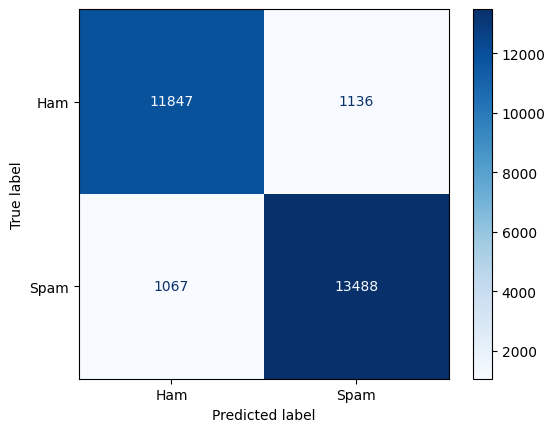

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.91     12983
           1       0.92      0.93      0.92     14555

    accuracy                           0.92     27538
   macro avg       0.92      0.92      0.92     27538
weighted avg       0.92      0.92      0.92     27538



In [30]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - accuracy: 0.9627 - loss: 0.1141 - val_accuracy: 0.9803 - val_loss: 0.0585
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9849 - loss: 0.0504 - val_accuracy: 0.9842 - val_loss: 0.0498
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9886 - loss: 0.0385 - val_accuracy: 0.9844 - val_loss: 0.0507
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9902 - loss: 0.0333 - val_accuracy: 0.9852 - val_loss: 0.0486
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9838 - val_loss: 0.0514
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9941 - loss: 0.0202 - val_accuracy: 0.9819 - val_loss: 0.0655
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9943 - loss: 0.0189 - val_accuracy: 0.9836 - val_loss: 0.0578
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9960 - loss: 0.0129 - 

In [31]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9624 - loss: 0.1083 - val_accuracy: 0.9829 - val_loss: 0.0553
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9845 - loss: 0.0525 - val_accuracy: 0.9841 - val_loss: 0.0516
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.9909 - loss: 0.0337 - val_accuracy: 0.9858 - val_loss: 0.0449
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9937 - loss: 0.0238 - val_accuracy: 0.9860 - val_loss: 0.0483
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9929 - loss: 0.0232 - val_accuracy: 0.9835 - val_loss: 0.0520
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9957 - loss: 0.0144 - val_accuracy: 0.9852 - val_loss: 0.0493
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9975 - loss: 0.0094 - val_accuracy: 0.9842 - val_loss: 0.0564
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9971 - loss: 0.0096 - 

In [32]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)


861/861 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


In [33]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9836589440046482


In [34]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     12983
        Spam       0.98      0.99      0.98     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



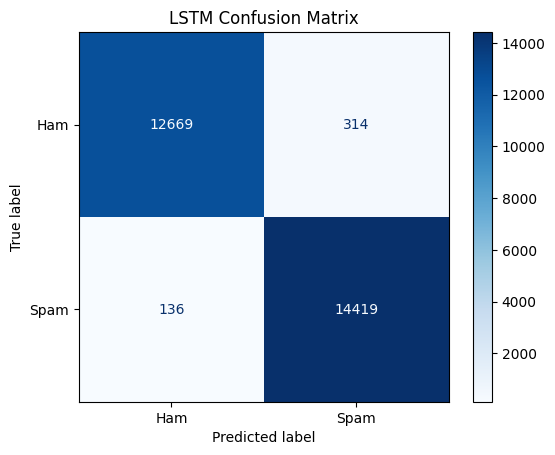

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()


In [36]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step


In [37]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)


GRU Accuracy: 0.9864913937105091


In [38]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))


GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99     12983
        Spam       0.99      0.99      0.99     14555

    accuracy                           0.99     27538
   macro avg       0.99      0.99      0.99     27538
weighted avg       0.99      0.99      0.99     27538



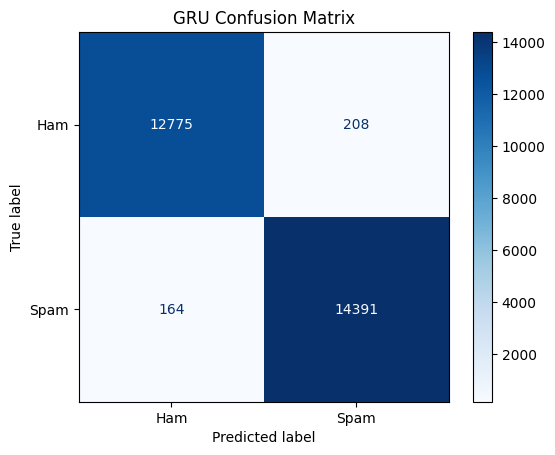

In [39]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()


In [40]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }


In [41]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)


861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.920001        0.922319     0.926692  0.924500
1        LSTM  0.983659        0.978687     0.990656  0.984635
2         GRU  0.986491        0.985752     0.988732  0.987240


In [42]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)


Best Model:
Model                  GRU
Accuracy          0.986491
Spam Precision    0.985752
Spam Recall       0.988732
Spam F1            0.98724
Name: 2, dtype: object


In [43]:
model_gru.save("gru_model.keras")

In [44]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [45]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [46]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)